# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


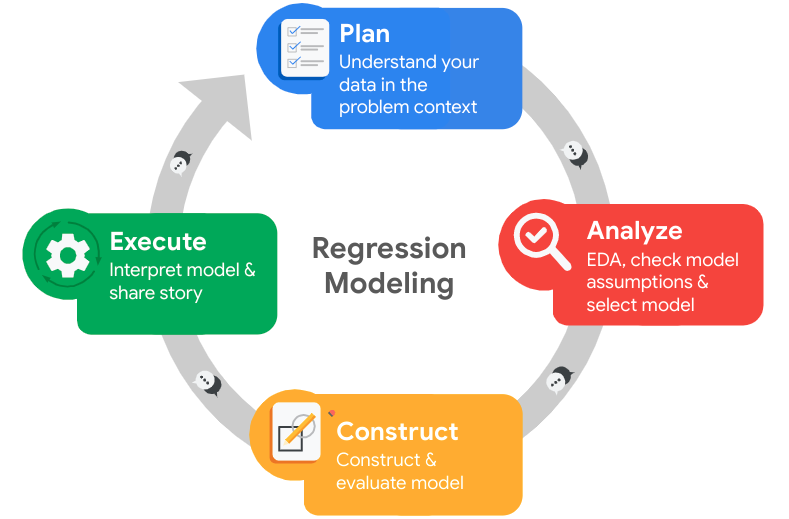

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




- The project stakeholders include the HR department at Salifort Motors.
- The goal of this project is to identify the reasons that likely cause employees to leave the company.
- The data contains 14999 rows and 10 columns. There are no missing values. There are over 5000 duplicate rows. After duplicate removal, the mean satisfaction level is 0.63, and the mean performance evaluation is 0.72.
- The functions provided by Pandas, as well as the data dictionary, are useful for performing an initial evaluation of the data.
- If the model that is developed through this project falsely identifies employees as potentially leaving when they actually do not plan to, the company might end up investing additional resources to keep those employees when there was actually no need. If the model misses certain employees who decide to leave, the situation will not be worse than the status quo. Additionally, there is a risk that by removing duplicate rows we are actually removing real data. But given the number of variables, it is very likely that the duplicate rows are actual duplicates.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

from xgboost import XGBClassifier
from xgboost import plot_importance

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe(include="all")


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0.rename(columns={"average_montly_hours": "avg_monthly_hours", "Work_accident": "work_accident", "Department": "department"}, inplace=True)


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
avg_monthly_hours        0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
df0[df0.duplicated(keep=False)]


,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [9]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated(keep=False)].head(10)


,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
# Based on the assumption that it is very unlikely that the same set of values can appear twice, 
# the duplicates are considered to be true duplicates and are therefore removed.
print(f"Number of rows before dropping duplicates: {df0.shape[0]}")
df0.drop_duplicates(keep="first", inplace=True)
print(f"Number of rows after dropping duplicates: {df0.shape[0]}")

# Display first few rows of new dataframe as needed
df0.head()


Number of rows before dropping duplicates: 14999
Number of rows after dropping duplicates: 11991


,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [11]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Check outliers

Check for outliers in the data.

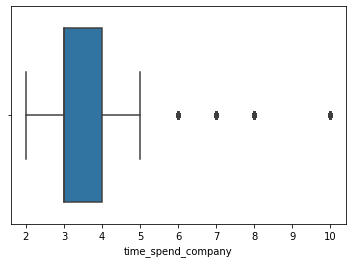

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
sns.boxplot(data=df0, x="time_spend_company")


In [13]:
# Determine the number of rows containing outliers
percentile25 = df0["time_spend_company"].quantile(0.25)
percentile75 = df0["time_spend_company"].quantile(0.75)
IQR = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR

outliers_filter = (df0["time_spend_company"] > upper_limit) | (df0["time_spend_company"] < lower_limit)
outliers_filter.sum()

824

In [14]:
df0.loc[outliers_filter, "time_spend_company"].unique()

array([ 6,  8, 10,  7])

In [15]:
print(f"Based on the thresholds used, there are {outliers_filter.sum()} outliers in the time_spend_company column.")

Based on the thresholds used, there are 824 outliers in the time_spend_company column.


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

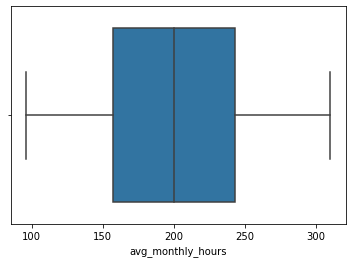

In [16]:
# Create a boxplot to visualize distribution of `avg_monthly_hours` and detect any outliers
sns.boxplot(data=df0, x="avg_monthly_hours")


In [17]:
# Determine the number of rows containing outliers
percentile25 = df0["avg_monthly_hours"].quantile(0.25)
percentile75 = df0["avg_monthly_hours"].quantile(0.75)
IQR = percentile75 - percentile25

# Calculate upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR

outliers_filter = (df0["avg_monthly_hours"] > upper_limit) | (df0["avg_monthly_hours"] < lower_limit)
outliers_filter.sum()

0

In [18]:
upper_limit

372.0

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




- The following observations were made regarding the relationships between variables:
 - The self-reported satisfaction level is on average 0.67 for employees who have stayed compared to 0.44 for employees who left, which means that the satisfaction level could be a strong indicator of whether an employee leaves or not.
 - The average score of the last performance review is roughly the same for both employees who stayed and those who left. 
 - Among the employees who left, a significant portion (43%) were contributing to two projects. This may indicate that some employees might have left because they were not given enough work and felt bored.
 - The maximum number of projects that an employee was contributing to is 7. All employees that contributed to 7 projects left. This indicates that assigning an employee to a high number of projects may increase the chances of that employee leaving.
 - The average monthly hours of employees who left the company are on average higher than for the employees who stayed. This indicates that some employees may have left because they felt they were working for too long.
 - The distribution of the time_spend_company variable shows that the largest fraction of employees leaving occurs after the 3rd year, followed by the 4th and 5th year.
 - The fraction of employees who left among those who had an accident is lower than for those who did not have an accident. This means that having a work accident is likely not a reason for employees to leave the company.
 - While the number of employees who received a promotion in the last 5 years is very small, the fraction of employees who left is clearly smaller among the employees who did receive a promotion compared to those who did not.
 - The fraction of employees who left is similar across all departments, indicating that whatever is pushing employees to leave is not specific to a certain department.
 - The fraction of employees leaving is highest within the group of employees earning a low salary, compared to a medium or high salary. This indicates that a low salary may be a reason pushing employees to leave.
 - The satisfaction level appears to have a relationship with the number of projects an employee contributes to. The satisfaction level is low for 2 projects as well as for 6 or more projects. The satisfaction level also appears to have a relationship with the number of years an employee spent at the company, with noticeable lower satisfaction level in the years 4, 5, and 6. Surprisingly, even though the salary has a relationship with whether an employee has left the company or not, there is no visible relationship between satisfaction level and salary.
 - There is a clear positive correlation between the average monthly hours and the number of projects an employee contributes. 

- Here are some observations regarding the distributions of the variables:
 - The satisfaction level and last evaluation variables are both left-skewed.
 - The number of projects and the average monthly hours are roughly bell-shaped.
 - The time spend company variable is right-skewed.
 - Around 15% of employees had a work accident.
 - Only 1.7% employees had a promotion in the last 5 years.
 - 92% of employees have an either low or medium salary.

- The only transformations applied to the data are the label encoding for the department and salary variables, so that a decision tree model can be trained. One-hot encoding was used for the department, while an ordinal encoding was used for the salary. No other transformations were (e.g. such as scaling of the float variables), since decision trees are not sensitive to the shape of distributions of the variables.

- Some purposes of EDA are the following:
 - Ensure that there are no missing values among the variables that will be used for building the model.
 - Identify and handle outlier values that may distort the model.
 - Identify duplicate values and handle them, to prevent them from distorting the model.
 - Validate the range of values of each variable to make sure that they are realistic and correspond to possible values.
 - Identify variables that have potentially a strong predictive power.
 
- Resources used include primarily the documentation of visualization libraries such as Seaborn.

- The main ethical consideration for this stage concerns the visualizations, which should be created such that they provide an unbiased representation of the data.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [19]:
# Get numbers of people who left vs. stayed
print(df0["left"].value_counts())

# Get percentages of people who left vs. stayed
print(df0["left"].value_counts(normalize=True))


0    10000
1     1991
Name: left, dtype: int64
0    0.833959
1    0.166041
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

In [20]:
df0.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [21]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [22]:
df0["work_accident"].value_counts()

0    10141
1     1850
Name: work_accident, dtype: int64

In [23]:
df0["work_accident"].value_counts(normalize=True)

0    0.845718
1    0.154282
Name: work_accident, dtype: float64

In [24]:
df0["promotion_last_5years"].value_counts()

0    11788
1      203
Name: promotion_last_5years, dtype: int64

In [25]:
df0["promotion_last_5years"].value_counts(normalize=True)

0    0.983071
1    0.016929
Name: promotion_last_5years, dtype: float64

In [26]:
df0["department"].value_counts()

sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: department, dtype: int64

In [27]:
df0["salary"].value_counts()

low       5740
medium    5261
high       990
Name: salary, dtype: int64

In [28]:
df0["salary"].value_counts(normalize=True)

low       0.478692
medium    0.438746
high      0.082562
Name: salary, dtype: float64

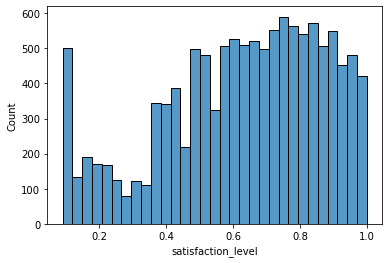

In [29]:
sns.histplot(df0["satisfaction_level"])


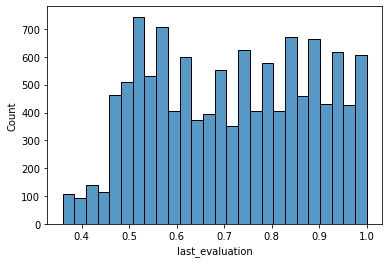

In [30]:
sns.histplot(df0["last_evaluation"])


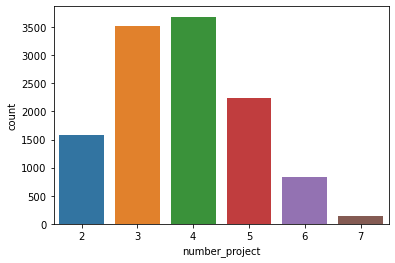

In [31]:
sns.countplot(
    data=df0,
    x="number_project",
    order=sorted(df0["number_project"].unique())
)


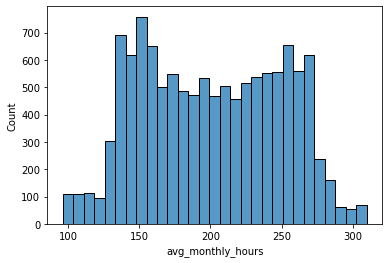

In [32]:
sns.histplot(df0["avg_monthly_hours"])


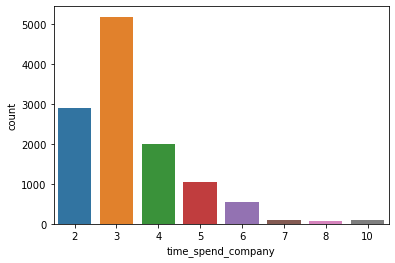

In [33]:
sns.countplot(
    data=df0,
    x="time_spend_company",
    order=sorted(df0["time_spend_company"].unique())
)


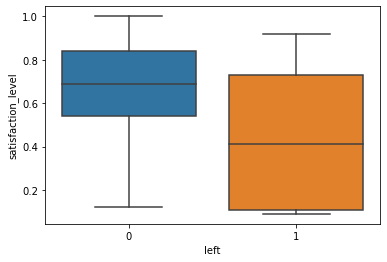

In [34]:
sns.boxplot(data=df0, x="left", y="satisfaction_level")


In [35]:
df0.groupby("left")["satisfaction_level"].mean().round(3)

left
0    0.667
1    0.440
Name: satisfaction_level, dtype: float64

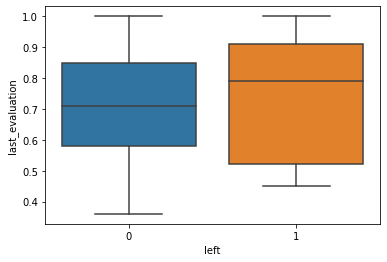

In [36]:
sns.boxplot(data=df0, x="left", y="last_evaluation")


In [37]:
df0.groupby("left")["last_evaluation"].mean().round(3)

left
0    0.716
1    0.722
Name: last_evaluation, dtype: float64

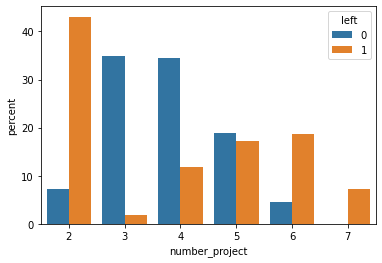

In [38]:
percent = pd.crosstab(df0["number_project"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="number_project",
    y="percent",
    hue="left",
)

In [39]:
percent

left,0,1
number_project,,
2,7.25,43.043697
3,34.82,1.908589
4,34.48,11.903566
5,18.90,17.227524
6,4.55,18.633852
7,0.00,7.282772


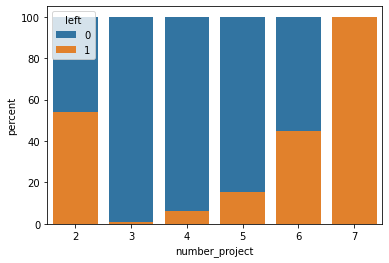

In [40]:
percent = pd.crosstab(df0["number_project"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="number_project", y="percent", hue="left",
    dodge=False
)

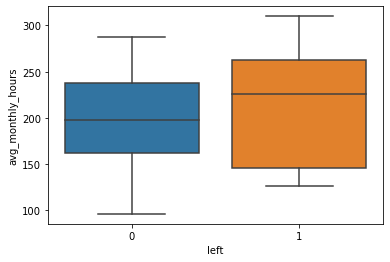

In [41]:
sns.boxplot(data=df0, x="left", y="avg_monthly_hours")


In [42]:
df0.groupby("left")["avg_monthly_hours"].mean()

left
0    198.94270
1    208.16223
Name: avg_monthly_hours, dtype: float64

As the mean of the average monthly hours is relatively close between the employees who left and those who stayed, we perform a hypothesis test to determine whether the difference is statistically significant.

The null and alternative hypotheses are the following:

*   $H_0$: There is no difference in the mean of the average monthly hours between the employees who left and those who stayed.
*   $H_A$: There is a difference in the mean of the average monthly hours between the employees who left and those who stayed.

The significance level is set to 0.05.

In [43]:
from scipy import stats

left = df0.loc[df0["left"] == 1, "avg_monthly_hours"]
stayed = df0.loc[df0["left"] != 1, "avg_monthly_hours"]
stats.ttest_ind(a=left, b=stayed, equal_var=False)

Ttest_indResult(statistic=6.368796832309121, pvalue=2.2679467569333412e-10)

Given the p-value is much smaller than 0.05, we can reject the null hypothesis and conclude that the mean of the average monthly hours between the employees who left and those who stayed is statistically different. In this case, the average monthly hours of employees who left the company are on average higher than for the employees who stayed.

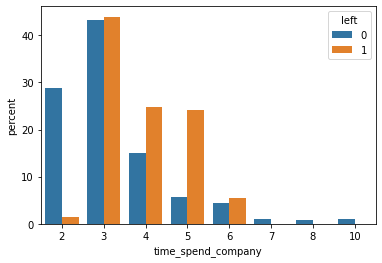

In [44]:
percent = pd.crosstab(df0["time_spend_company"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="time_spend_company",
    y="percent",
    hue="left",
)

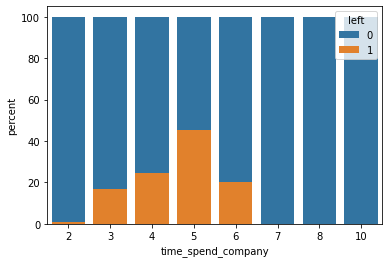

In [45]:
percent = pd.crosstab(df0["time_spend_company"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="time_spend_company", y="percent", hue="left",
    dodge=False
)

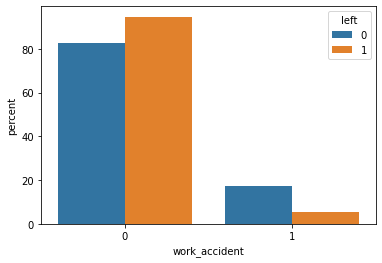

In [46]:
percent = pd.crosstab(df0["work_accident"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="work_accident",
    y="percent",
    hue="left",
)

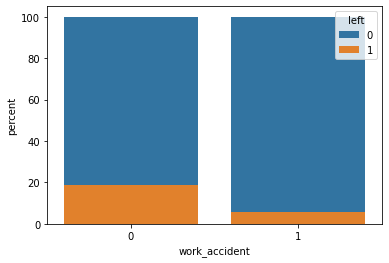

In [47]:
percent = pd.crosstab(df0["work_accident"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="work_accident", y="percent", hue="left",
    dodge=False
)

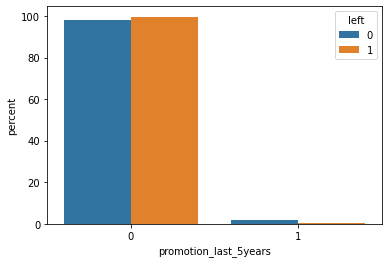

In [48]:
percent = pd.crosstab(df0["promotion_last_5years"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="promotion_last_5years",
    y="percent",
    hue="left",
)

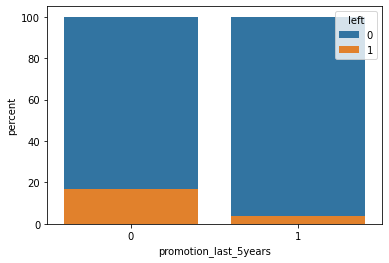

In [49]:
percent = pd.crosstab(df0["promotion_last_5years"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="promotion_last_5years", y="percent", hue="left",
    dodge=False
)

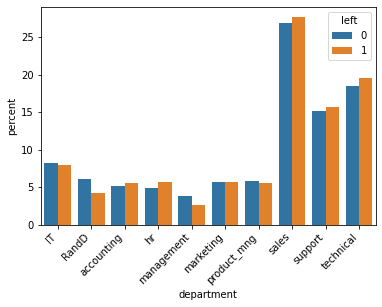

In [50]:
percent = pd.crosstab(df0["department"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="department",
    y="percent",
    hue="left",
)
plt.xticks(rotation=45, ha="right")
plt.show()

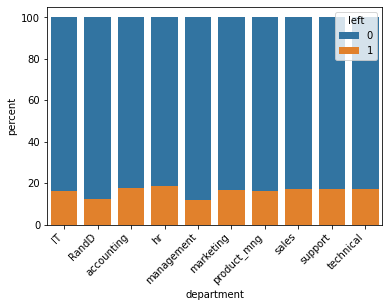

In [51]:
percent = pd.crosstab(df0["department"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="department", y="percent", hue="left",
    dodge=False
)
plt.xticks(rotation=45, ha="right")
plt.show()

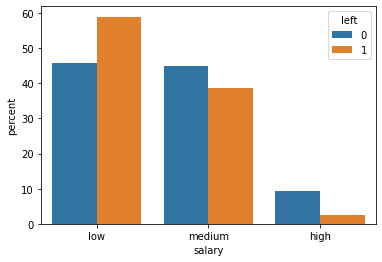

In [52]:
percent = pd.crosstab(df0["salary"], df0["left"], normalize="columns").mul(100)

percent_long = percent.stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="salary",
    y="percent",
    hue="left",
    order=["low", "medium", "high"]
)

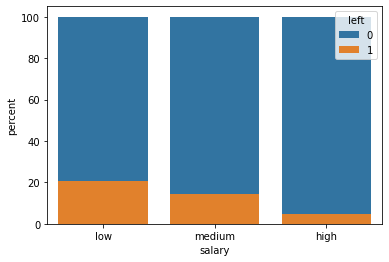

In [53]:
percent = pd.crosstab(df0["salary"], df0["left"], normalize="index").mul(100)

percent_long = percent[percent.columns[::-1]].cumsum(axis=1).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="salary", y="percent", hue="left",
    dodge=False,
    order=["low", "medium", "high"]
)

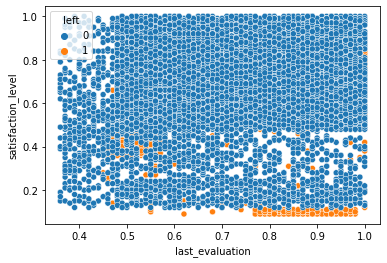

In [54]:
sns.scatterplot(data=df0, x="last_evaluation", y="satisfaction_level", hue="left")

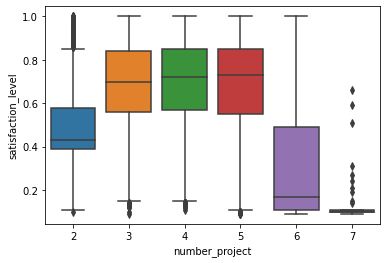

In [55]:
sns.boxplot(data=df0, x="number_project", y="satisfaction_level")

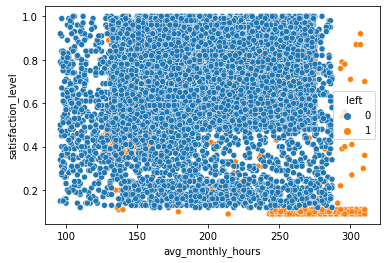

In [56]:
sns.scatterplot(data=df0, x="avg_monthly_hours", y="satisfaction_level", hue="left")

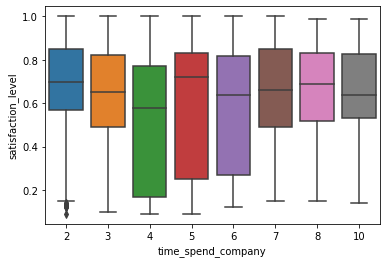

In [57]:
sns.boxplot(data=df0, x="time_spend_company", y="satisfaction_level")

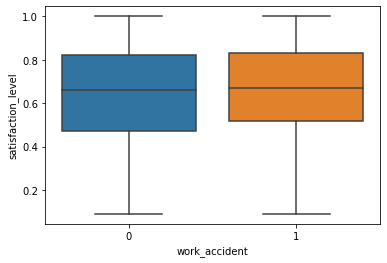

In [58]:
sns.boxplot(data=df0, x="work_accident", y="satisfaction_level")

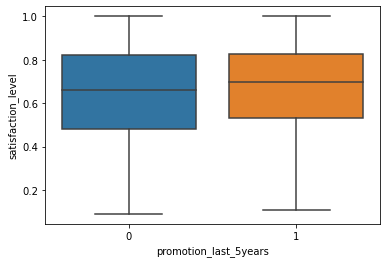

In [59]:
sns.boxplot(data=df0, x="promotion_last_5years", y="satisfaction_level")

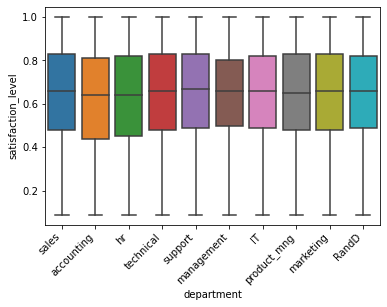

In [60]:
sns.boxplot(data=df0, x="department", y="satisfaction_level")
plt.xticks(rotation=45, ha="right")
plt.show()

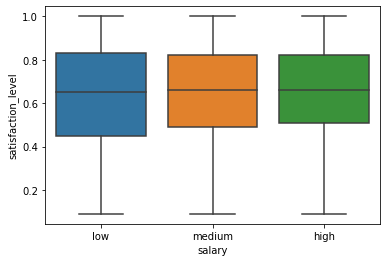

In [61]:
sns.boxplot(data=df0, x="salary", y="satisfaction_level", order=["low", "medium", "high"])

In [62]:
df0.groupby("salary")["satisfaction_level"].mean().round(3)

salary
high      0.643
low       0.623
medium    0.635
Name: satisfaction_level, dtype: float64

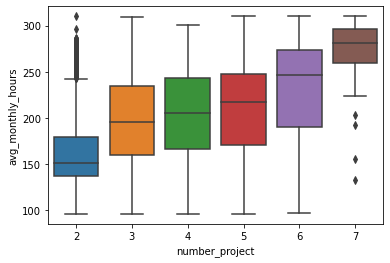

In [63]:
sns.boxplot(data=df0, x="number_project", y="avg_monthly_hours")

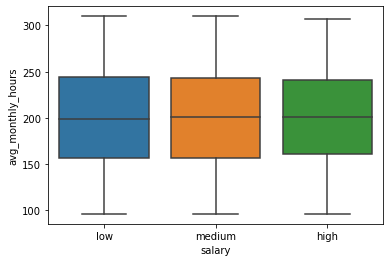

In [64]:
sns.boxplot(data=df0, x="salary", y="avg_monthly_hours", order=["low", "medium", "high"])

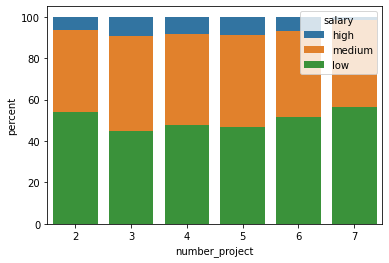

In [65]:
percent = pd.crosstab(df0["salary"], df0["number_project"], normalize="columns").mul(100).reindex(["low", "medium", "high"])

percent_long = percent.cumsum(axis=0).stack().reset_index(name="percent")

sns.barplot(
    data=percent_long,
    x="number_project", y="percent", hue="salary",
    dodge=False,
    hue_order=["high", "medium", "low"]
)

### Insights

See observations regarding relationships between variables described at the beginning of this section.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



- All independent variables were retained except for the last evaluation and department, as they did not show a strong relationship with the target variable.
- As decision trees and random forest models are used, there are no particular assumptions that need to be met in order for them to be used.
- After some hyperparameter tuning, all 3 models that were trained achieved at least a score of 0.9 on all metrics that were evaluated. They all performed even slightly better on the vallidation set. This indicates that the models are not overfitting and have a strong predictive power.
- The only surprising aspect is that all 3 models have the exact same scores when evaluated on the validation set. After more detailed checking, it turns out that the decision tree and random forest indeed provide the exact same predictions, while the XGBoost has just 4 different predictions (which still results in the metrics being identical).

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

As the target variable is binary, this is a binary classification problem.

### Identify the types of models most appropriate for this task.

A classifier is the most appropriate model for this task. For this project, a decision tree classifier will be trained, as well as a random forest classifier and a XGBoost classifier.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [66]:
# Create new dataframe that contains only the columns that will be used for the model
# As the last evaluation and department did not show a strong relationship with the target variable, they are dropped from the dataframe.
cols_to_keep = ["satisfaction_level", "number_project", "avg_monthly_hours", "time_spend_company", "work_accident", "left", "promotion_last_5years", "salary"]
df1 = df0[cols_to_keep].copy()

In [67]:
# Encode salary column
mapping = {"low": 0, "medium": 1, "high": 2}
df1["salary"] = df1["salary"].map(mapping)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11991 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   number_project         11991 non-null  int64  
 2   avg_monthly_hours      11991 non-null  int64  
 3   time_spend_company     11991 non-null  int64  
 4   work_accident          11991 non-null  int64  
 5   left                   11991 non-null  int64  
 6   promotion_last_5years  11991 non-null  int64  
 7   salary                 11991 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 1.1 MB


In [68]:
# Check class balance of target variable
df1["left"].value_counts(normalize=True)

0    0.833959
1    0.166041
Name: left, dtype: float64

In [69]:
# Isolate target variable (y)
y = df1["left"]

# Isolate the features (X)
X = df1.drop("left", axis=1)

# Split into train and test sets
X_full_train, X_test, y_full_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Split the full_train set into a train and validation set. The validation set will be used to compare the 
# different models after their hyperparameters have been optimized using cross-validation on the train set.
X_train, X_val, y_train, y_val = train_test_split(X_full_train, y_full_train, stratify=y_full_train, test_size=0.25, random_state=42)

In [70]:
# Initialize DataFrame that will store the training and validation results for all models
all_metrics = pd.DataFrame(columns=['Model', "F1", "Accuracy", "Precision", "Recall", "ROC AUC"])

In [71]:
# Define function for creating DataFrame that stores training results for one model.
def get_training_metrics(model_name, model_object):
    """
    Returns a DataFrame containing the training metrics of the passed model.
    
    Args:
        model_name: Name of the model.
        model_object: Fitted GridSearchCV object.

    Returns:
        A DataFrame with the F1, Accuracy, Precision, Recall, and ROC AUC scores
        for the model with the best mean F1 score across all validation folds.  
    """
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_cv_metrics = cv_results.loc[model_object.best_index_]
    metrics_df = pd.DataFrame(
        {"Model": [model_name],
         "F1": [best_cv_metrics["mean_test_f1"]],
         "Accuracy": [best_cv_metrics["mean_test_accuracy"]],
         "Precision": [best_cv_metrics["mean_test_precision"]],
         "Recall": [best_cv_metrics["mean_test_recall"]],
         "ROC AUC": [best_cv_metrics["mean_test_roc_auc"]]}
     )

    return metrics_df

In [72]:
# Define function for creating DataFrame that stores computed metrics for one model.
def compute_metrics(model_name, model_object, X, y):
    """
    Returns a DataFrame containing the validation metrics of the passed model.
    
    Args:
        model_name: Name of the model.
        model_object: Fitted GridSearchCV object.
        X: Contains the feature values.

    Returns:
        A DataFrame with the F1, Accuracy, Precision, Recall, and ROC AUC scores
        computed on the predicted values based on the provided data.  
    """
    y_pred = model_object.predict(X)
    
    metrics_df = pd.DataFrame(
        {"Model": [model_name],
         "F1": [f1_score(y, y_pred)],
         "Accuracy": [accuracy_score(y, y_pred)],
         "Precision": [precision_score(y, y_pred)],
         "Recall": [recall_score(y, y_pred)],
         "ROC AUC": [roc_auc_score(y, y_pred)]}
     )

    return metrics_df


In [73]:
scoring = {"f1", "accuracy", "precision", "recall", "roc_auc"}

#### Train a Decision Tree Classifier

In [74]:
# dt_param_grid = {
#     "max_depth": [None, 4, 8, 12, 16],
#     "min_samples_split": [10, 60, 65, 70, 75, 80],
#     "min_samples_leaf": [1, 5, 10],
# }

dt_param_grid = {
    "max_depth": [8],
    "min_samples_split": [65],
    "min_samples_leaf": [1],
}

dt = DecisionTreeClassifier(random_state=42)

dt_cv = GridSearchCV(
    dt,
    dt_param_grid,
    scoring=scoring,
    cv=5,
    refit="f1",
    n_jobs=-1,
    verbose=2
)

dt_cv.fit(X_train, y_train)

dt_best = dt_cv.best_estimator_

print("Best params:", dt_cv.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Best params: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 65}


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.0s remaining:    7.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.2s finished


In [75]:
dt_train_metrics = get_training_metrics("Decision Tree Training", dt_cv)
all_metrics = pd.concat([all_metrics, dt_train_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583


In [76]:
dt_val_metrics = compute_metrics("Decision Tree Validation", dt_best, X_val, y_val)
all_metrics = pd.concat([all_metrics, dt_val_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074


The model performed slightly better on the validation dataset than on the training dataset, indicating that there is no overfitting of the training data.

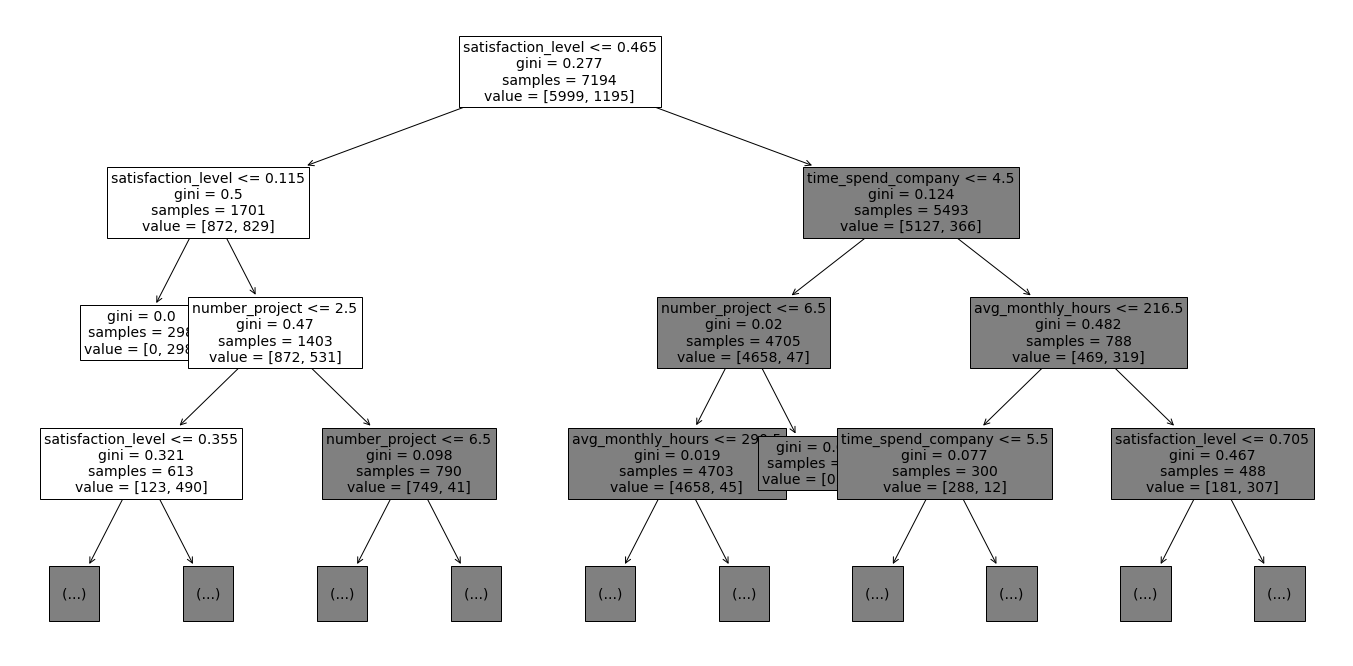

In [77]:
plt.figure(figsize=(24,12))
plot_tree(dt_best, max_depth=3, fontsize=14, feature_names=X.columns);

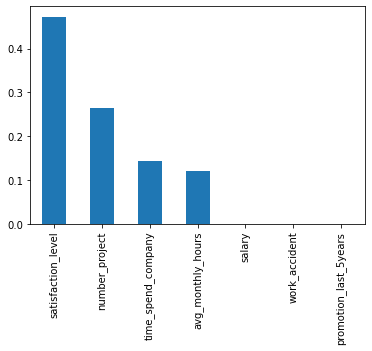

In [78]:
feature_importances = pd.Series(dt_best.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots()
feature_importances.plot.bar(ax=ax);

#### Train a Random Forest Classifier

In [79]:
# rf_param_grid = {
#     'n_estimators' : [75, 100, 125], 
#     'max_depth' : [5, 10, 15, 20, 30],
#     'min_samples_split' : [30, 40, 50, 60, 100],
#     'min_samples_leaf' : [10, 15, 20, 25, 30],
#     'max_features' : ["sqrt", None],
#     'max_samples' : [0.6, 0.7, 0.8, 0.9, 1]
# }

# rf_param_grid = {
#     'n_estimators' : [80, 100, 120], 
#     'max_depth' : [12, 15, 18],
#     'min_samples_split' : [50, 60, 70],
#     'min_samples_leaf' : [5, 10, 15],
#     'max_features' : ["sqrt", None],
#     'max_samples' : [0.75, 0.8, 0.85]
# }

# rf_param_grid = {
#     'n_estimators' : [70, 80, 90], 
#     'max_depth' : [10, 12, 14],
#     'min_samples_split' : [40, 50, 60],
#     'min_samples_leaf' : [3, 5, 7],
#     'max_features' : ["sqrt", None],
#     'max_samples' : [0.8, 0.85, 0.9]
# }

# rf_param_grid = {
#     'n_estimators' : [65, 70, 75], 
#     'max_depth' : [9, 10, 11],
#     'min_samples_split' : [35, 40, 45],
#     'min_samples_leaf' : [2, 3, 4],
#     'max_features' : [None],
#     'max_samples' : [0.82, 0.85, 0.88]
# }

# rf_param_grid = {
#     'n_estimators' : [55, 60, 65], 
#     'max_depth' : [7, 8, 9],
#     'min_samples_split' : [25, 30, 35],
#     'min_samples_leaf' : [1, 2, 3],
#     'max_features' : [None],
#     'max_samples' : [0.80, 0.82, 0.84]
# }

rf_param_grid = {
    'n_estimators' : [60], 
    'max_depth' : [8],
    'min_samples_split' : [25],
    'min_samples_leaf' : [1],
    'max_features' : [None],
    'max_samples' : [0.82]
}


rf = RandomForestClassifier(random_state=42)

rf_cv = GridSearchCV(
    rf,
    rf_param_grid,
    scoring=scoring,
    cv=5,
    refit='f1',
    n_jobs=-1,
    verbose=2
)

rf_cv.fit(X_train, y_train)

rf_best = rf_cv.best_estimator_

print("Best params:", rf_cv.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.9s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.0s finished


Best params: {'max_depth': 8, 'max_features': None, 'max_samples': 0.82, 'min_samples_leaf': 1, 'min_samples_split': 25, 'n_estimators': 60}


In [80]:
rf_train_metrics = get_training_metrics("Random Forest Training", rf_cv)
all_metrics = pd.concat([all_metrics, rf_train_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734


In [81]:
rf_val_metrics = compute_metrics("Random Forest Validation", rf_best, X_val, y_val)
all_metrics = pd.concat([all_metrics, rf_val_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074


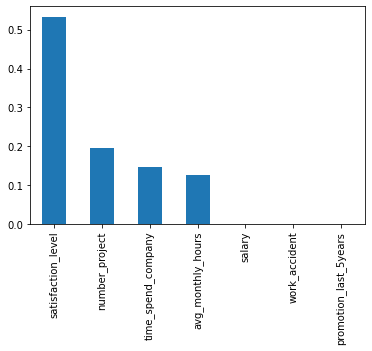

In [82]:
feature_importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots()
feature_importances.plot.bar(ax=ax);

#### Train a XGBoost Classifier

In [83]:
# xgb_param_grid = {
#     'max_depth': [2, 6, 10, 14],
#     'min_child_weight': [2, 5, 8],
#     'learning_rate': [0.1, 0.3, 0.5],
#     'n_estimators': [5, 10, 50],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9]
# }

# xgb_param_grid = {
#     'max_depth': [4, 6, 8],
#     'min_child_weight': [1, 2, 4],
#     'learning_rate': [0.25, 0.3, 0.35],
#     'n_estimators': [5, 10, 50],
#     'subsample': [0.85, 0.9, 0.95, 1.0],
#     'colsample_bytree': [0.75, 0.8, 0.85]
# }

# xgb_param_grid = {
#     'max_depth': [6, 8, 10],
#     'min_child_weight': [1, 2, 4],
#     'learning_rate': [0.2, 0.25, 0.3],
#     'n_estimators': [50, 75, 100],
#     'subsample': [0.9, 0.95, 1.0],
#     'colsample_bytree': [0.7, 0.75, 0.8]
# }

xgb_param_grid = {
    'max_depth': [8],
    'min_child_weight': [1],
    'learning_rate': [0.25],
    'n_estimators': [50],
    'subsample': [1.0],
    'colsample_bytree': [0.75]
}

xgb = XGBClassifier(objective='binary:logistic', random_state=42)

xgb_cv = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring=scoring,
    cv=5,
    refit = 'f1',
    n_jobs=-1,
    verbose=2
)

xgb_cv = xgb_cv.fit(X_train, y_train)

xgb_best = xgb_cv.best_estimator_

print("Best params:", xgb_cv.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.3s finished


Best params: {'colsample_bytree': 0.75, 'learning_rate': 0.25, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 1.0}


In [84]:
xgb_train_metrics = get_training_metrics("XGBoost Training", xgb_cv)
all_metrics = pd.concat([all_metrics, xgb_train_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,XGBoost Training,0.938337,0.980122,0.965848,0.912971,0.979514


In [85]:
xgb_val_metrics = compute_metrics("Random Forest Validation", xgb_best, X_val, y_val)
all_metrics = pd.concat([all_metrics, xgb_val_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,XGBoost Training,0.938337,0.980122,0.965848,0.912971,0.979514
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074


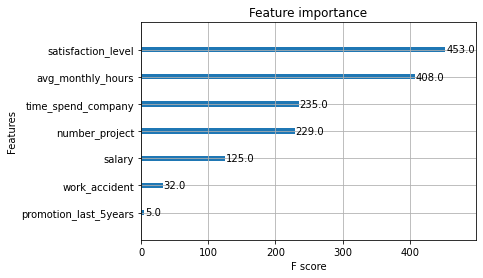

In [86]:
plot_importance(xgb_cv.best_estimator_)

#### Model Selection and Final Evaluation

In [87]:
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,XGBoost Training,0.938337,0.980122,0.965848,0.912971,0.979514
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074


Given that the performance on the validation set is identical for all 3 models, the decision tree is selected as final model, due to the fact that is simpler and easier to interpret than the other two models.

In [88]:
final_model = DecisionTreeClassifier(max_depth=8, min_samples_split=65, min_samples_leaf=1, random_state=42)
final_model.fit(X_full_train, y_full_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=8, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=65,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=42, splitter='best')

In [89]:
test_metrics = compute_metrics("Decision Tree Testing", final_model, X_test, y_test)
all_metrics = pd.concat([all_metrics, test_metrics])
all_metrics

,Model,F1,Accuracy,Precision,Recall,ROC AUC
0,Decision Tree Training,0.942752,0.981651,0.976057,0.912134,0.973583
0,Decision Tree Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Random Forest Training,0.941939,0.981373,0.974349,0.912134,0.977734
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,XGBoost Training,0.938337,0.980122,0.965848,0.912971,0.979514
0,Random Forest Validation,0.954839,0.985405,0.981432,0.929648,0.963074
0,Decision Tree Testing,0.953608,0.984994,0.978836,0.929648,0.962825


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



- All three models show that the self-reported satisfaction level is the most important feature for predicting whether an employee will leave the company. It is closely followed by the number of projects, the time spent at the company, and the average monthly hours worked. The salary is only indicated as important in the XGBoost model, which was unexpected, given that a high fraction of employees who left had a low salary (more than for those who stayed).
- Based on the data analysis and model training, the recommendations for the company are the following:
 - Perform regular survey to assess the level of satisfaction of employees, as this is a strong indicator as to whether they will leave or not. A more detailed analysis of the satisfaction score could be conducted to determine at what threshold an employee is more likely to leave than stay.
 - Assign employees to at least 3 projects, but limit them to 5. The analysis showed that employees who contribute to a number of projects that fall outside of that range are much more likely to leave. Employees who contribute to only 2 projects are likely feeling understimulated, while those who have more than 5 projects are likely feeling overworked. Additionally, the number of projects is positively correlated with the average monthly hours worked, and the higher the number of hours worked, the more likely an employee is going to leave the company. So by maintaining the number of projects between 3 and 5, the monthly hours will also be maintained within a range where employees are more likely to stay than leave.
 - The time spent at the company is also a strong indicator as to whether an employee will leave or not. An employee becomes more and more likely to leave starting from the 3rd year. This means that employees who have stayed at least two years should be assessed regularly regarding their satisfaction level, and the number of projects they are contributing to should be closely managed to ensure that they stay.
- Given the high performance scores obtained for the final model, there is only little room for improvement. An easy first step would be to refit the model while including the two features that were previously excluded, as they might slightly increase the performance, even though they did not appear to be important features based on the EDA.
- Based on the EDA, it appears that the satisfaction level is related to the number of projects and time spent at the company. A more detailed employee survey could be carried out to determine the reasons that contribute to a high or a low satisfacation.
- The main ethical considerations at this stage concerns how the company might treat employees who are predicted as wanting to leave: those employees might get proposed some additional benefits compared to employees who are predicted as wanting to stay. That may result in an unfair treatment of employees, resulting in feelings of resentment for those who have committed to staying with the company without getting any additional benefits.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The decision tree was selected as final model, given that all models performed equally well on the validation set. When evaluated on the test set, it achieved an F1 score of 0.954, which is very high.

The analysis of importance of features showed that the most important feature is the self-reported satisfaction level, followed by the number of projects, time spent at the company, and the average monthly hours. These findings are in line with the visualizations created during the EDA phase. However, the salary did not show up as being an important feature, which was surprising given the distributions observed in the EDA phase.

### Conclusion, Recommendations, Next Steps

To improve employee retention, it is first of all recommended to conduct regular surveys (at least once a year) to determine the satisfaction level of each employee, as this is the strongest indicator as to whether an employee will leave or not.

The number of projects that each employee contributes to should be maintained between 3 and 5, as employees who are contributing to those numbers of projects are less likely to leave. Limiting the number of projects to 5 will also likely prevent the average monthly hours from reaching high levels which are associated with employees who leave.

Attention should be paid to employees who have been at the company at least 2 years, since employees tend to start leaving from year 3 onwards. By ensuring that employees who have been at least 2 years at the company are contributing to the ideal number of projects mentioned above, this will increase the chances of them staying.

While the model does not identify salary as being an important feature, the analysis of the data showed that the highest fraction of employees who leave have a low salary. The fraction of employees leaving who had a medium or high salary is lower than for employees who stayed, which means that offering a promotion to a medium or high salary might be a good incentive for retaining employees.

It would be worth investigating in more detail what aspects contribute to the satisfaction level. Also, a more detailed analysis of the satisfaction level number could be carried out in order to determine the threshold below which an employee is more likely to leave than to stay. This will enable to decide with more confidence when to incentivize an employee to stay.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.